# Linear Environment Findings

The purpose of this paper is to disseminate our findings from the replication of the Bundesbankpaper’s linear SVAR(2) environment.

## Methodology

In this section we will divulge the general mathematical methods used to by both the referencepaper and our replica.

### Static Assumptions

The Bundesbank paper implements a set of very simple static parameters which we abide byin replicating the paper’s methodology. the sample data timespan is Q3 1987 until Q2 2007. In addition all data has a quarterly observation frequency. Conformity to these requirements is enforcedin the data through transformations and data aggregation.

### Data Preparation

In replicating the Bundesbank paper’s SVAR model for the linear environment, the first step isto properly fetch, clean, and transform the data as done in the reference paper. our input series are {${\pi_t,Y_t,Y_t^\ast,i_t}$} for inflation, real output, potential output, and interest rate, respectively. Asspecified by the reference paper, we use the GDP Implicit Price Deflator for inflation and specify the ‘pc1’ transformation to return year over year percent change data. We do this to satisfy: ${\pi_t=100\times(\tfrac{P^t}{P_{t-4}}-1)}$ while maintaining minimal boilerplate code. Similarly we use the Federal Funds Effective Rate, Percent for interest rate, ${i_t}$ and specify the “avg” aggregation method since the series has a native frequency of monthly. For real output ${Y_t}$ and potential output ${Y_t^\ast}$, we use Real GDP and Potential GDP respectively. in order to create our output gap ${y_t}$, we calculate the GDP gap (percent deviation) as ${y_t=100\times(\tfrac{Y^t}{Y_t^\ast}-1)}$. Our final set of time series are now {${\pi_t,y_t,i_t}$} for inflation, output gap, and interest rate.

### SVAR Model

In replicating the Bundesbank paper we implement a restricted two‑equation linear SVAR (${y,\pi}$) estimated by OLS (Ordinary Least Squares) with recursive lag pruning for ${t − 2}$ terms in which ${p > \alpha}$ for ${\alpha = 0.10}$. It should be noted that the term ${i_t}$ is only used as a regressor in the linear environment. the SVAR(2) structure is as follows mathematically. The linear economy is represented using ${\hat{f^m}=C^m+\alpha^{m`}s_t^m}$ where ${\hat{f^m}}$ represents a linear function comprised of the collected inputs from the ${s_t^m}$ vector. ${C^m}$ and ${\alpha^m}$ for ${m\in\{\pi,y}\}$ are the constant and vector coeﬀicients. If we expand ${s_t^m}$ for ${m\in\{\pi,y}\}$ we get the input vectors: $s_t^y= (y_{t-1},\pi_{t-1},i_{t−1}, i{t−2})$ and $s_t^\pi=($y_t, y_{t−1},y{t-2},\pi_{t−1},\pi_{t−2},i_{t−1})$. It is important to note that the only vector which relies on a contemporaneous term is $s_t^\pi$ which contains contemporaneous ${y_t}$. If we substitute our input vectors for the linear environment we arrive at the linear system as follows: ${y_t=C^y+\alpha_{y,1}^y y_{t−1}+ \alpha_{\pi,1}^y\pi_{t−1}+\alpha_{i,1}^y i_{t−1}+\alpha_{i,2}^y i_{t−2}+\epsilon_t^y}$ and ${\pi_t=C^\pi+\alpha_{y,0}^\pi y_t+\alpha_{y,1}^\pi y_t−1+\alpha_{y,2}^\pi y_{t-2}+\alpha_{\pi,1}^\pi \pi_{t−1}+\alpha_{\pi,2}^\pi \pi_{t−2}+\alpha_{i,1}^\pi i_{t−1}+\epsilon_𝑡^\pi}$ which can be vizualised as:

$$
{\hat{f}^m = {C}^m + {\alpha}^{m'}{s_t^m}}, {m}{\in}{\{ \pi, y \}} =
$$

$$
\begin{cases}
  {C^y} + {{\alpha}_{y,1}^y}{y_{t-1}} + {{\alpha}_{{\pi},1}^y}{{\pi}_{t-1}} + {{\alpha}_{i,1}^y}{i_{t-1}} + {{\alpha}_{i,2}^y}{i_{t-2}} + {\epsilon}_t^y & m = y \\
  {C^{\pi}} + {{\alpha}_{y,0}^{\pi}}{y_t} + {{\alpha}_{y,1}^{\pi}}{y_{t-1}} + {{\alpha}_{y,2}^{\pi}}{y_{t-2}} + {{\alpha}_{{\pi},1}^{\pi}}{{\pi}_{t-1}} + {{\alpha}_{{\pi},2}^{\pi}}{{\pi}_{t-2}} + {{\alpha}_{i,1}^{\pi}}{i_{t-1}} + {\epsilon}_t^{\pi} & m = \pi
\end{cases}
$$

## Results & Comparison

In this section we will explore the actual results from the code execution of our sample data and model. The general form of the output equations are as follows from $\hat{f}^m$

Output gap equation:

$y_t={C^y} + {{\alpha}_{y,1}^y}{y_{t-1}} + {{\alpha}_{{\pi},1}^y}{{\pi}_{t-1}} + {{\alpha}_{i,1}^y}{i_{t-1}} + {{\alpha}_{i,2}^y}{i_{t-2}} + {\epsilon}_t^y$

Inflation equation (note the contemporaneous $y_t$ term):

$\pi_t={C^{\pi}} + {{\alpha}_{y,0}^{\pi}}{y_t} + {{\alpha}_{y,1}^{\pi}}{y_{t-1}} + {{\alpha}_{y,2}^{\pi}}{y_{t-2}} + {{\alpha}_{{\pi},1}^{\pi}}{{\pi}_{t-1}} + {{\alpha}_{{\pi},2}^{\pi}}{{\pi}_{t-2}} + {{\alpha}_{i,1}^{\pi}}{i_{t-1}} + {\epsilon}_t^{\pi}$

### OLS Sample Results (SVAR)

The OLS model when given the sample data yielded the following for ${\hat{f}^m}$:

In [5]:
%%capture
%run -i linear_environment.ipynb # Import the linear environment

In [6]:
display(Markdown(y_t_eq_str))
display(Markdown(pi_t_eq_str))


${y_t} = 0.3473 + (0.9318)y_{t-1} + (-0.0595){\pi}_{t-1} + (0.2003)i_{t-1} + (-0.2385)i_{t-2} + {\epsilon}_t^y$



${\pi}_t = 0.1178 + (-0.0712)y_t + (0.2092)y_{t-1} + (-0.1110)y_{t-2} + (1.3027){\pi}_{t-1} + (-0.3245){\pi}_{t-2} + (-0.0146)i_{t-1} + {\epsilon}_t^{\pi}$


Note that none of the $t−2$ terms were dropped as they all had significant p values relative to our $p>\alpha$ parameter. This is a relatively close output when compared with the Bundesbank results as shown below:

In [7]:
display(Markdown(table_nine_str))


| Parameters                     | Bundesbank Estimate | p-Value | Local OLS Estimate                             | p-Value                                        |
|--------------------------------|---------------------|---------|------------------------------------------------|------------------------------------------------|
| **Output gap equation**        |                     |         |                                                |                                                |
| $C^y$                          | 0.3834              | 0.0351  | 0.3473               | 0.0582              |
| $a^y_{y,1}$                  | 0.9084              | 0.0000  | 0.9318              | 0.0000             |
| $a^y_{\pi,1}$                | -0.1437             | 0.1409  | -0.0595             | 0.4922            |
| $a^y_{i,1}$                  | 0.2726              | 0.0661  | 0.2003              | 0.1980             |
| $a^y_{i,2}$                  | -0.2896             | 0.0313  | -0.2385              | 0.0875             |
| $\bar{R}^2$                  | 0.9100              |         | 0.8889                      |                                                |
| MSE                            | 0.2108              |         | 0.2260                     |                                                |
| $\hat\sigma_{\varepsilon_1}$ | 0.2136              |         | 0.4754                  |                                                |
| DW                             | 1.8206              |         | 1.8220          |                                                |
| LM(1)                          | 3.1037              | 0.1644  | 0.6285  | 0.4305  |
| **Inflation equation**         |                     |         |                                                |                                                |
| $C^\pi$                        | 0.1035              | 0.1659  | 0.1178              | 0.1166             |
| $a^\pi_{y,0}$                | -0.0655             | 0.1578  | -0.0712                  | 0.1209                 |
| $a^\pi_{y,1}$                | 0.1970              | 0.0048  | 0.2092             | 0.0024            |
| $a^\pi_{y,2}$                | -0.1121             | 0.0163  | -0.1110             | 0.0210            |
| $a^\pi_{\pi,1}$              | 1.2970              | 0.0000  | 1.3027            | 0.0000           |
| $a^\pi_{\pi,2}$              | -0.3116             | 0.0076  | -0.3245            | 0.0044           |
| $a^\pi_{i,1}$                | -0.0122             | 0.4174  | -0.0146             | 0.3460            |
| $\bar{R}^2$                  | 0.9450              |         | 0.9511                     |                                                |
| MSE                            | 0.0326              |         | 0.0346                    |                                                |
| $\hat\sigma_{\varepsilon_2}$ | 0.0330              |         | 0.1861                 |                                                |
| DW                             | 2.1095              |         | 2.1028         |                                                |
| LM(1)                          | 2.5542              | 0.0696  | 1.5639 | 0.2153 |

\* Residual std dev from OLS output.

### Out of Sample Forecast

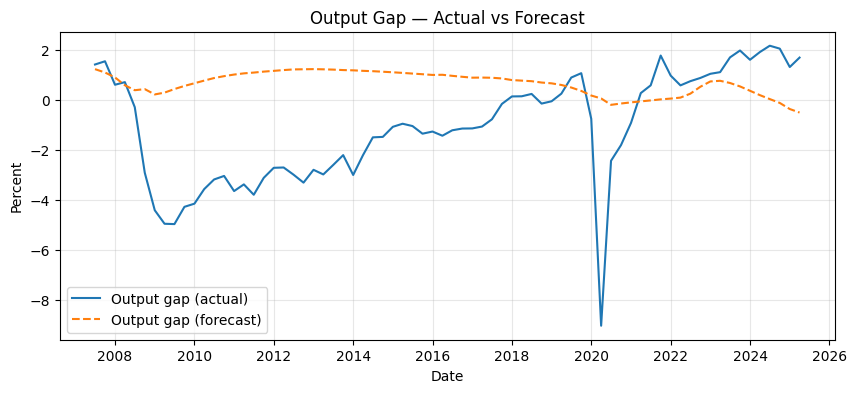

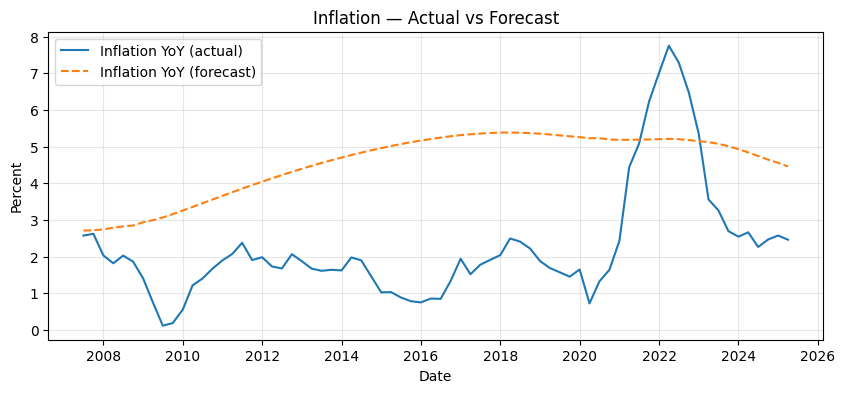

In [8]:
display(figure_five)
display(figure_six)

From this we can see that the SVAR model is a good measure of cyclical stability but conversely does not reflect reaction to system shocks. This is a reflection of $\hat{f}^m$ lacking a structural input vector specifically for shocks. This is expected to be accounted for in the non-linear environment through reinforcement learning.

### Squared Errors Replication

As a final check of adherence to the papers methodology and performance specifications we recreate figure 4 and figure 5 from the reference paper with our sample data and model as shown below:

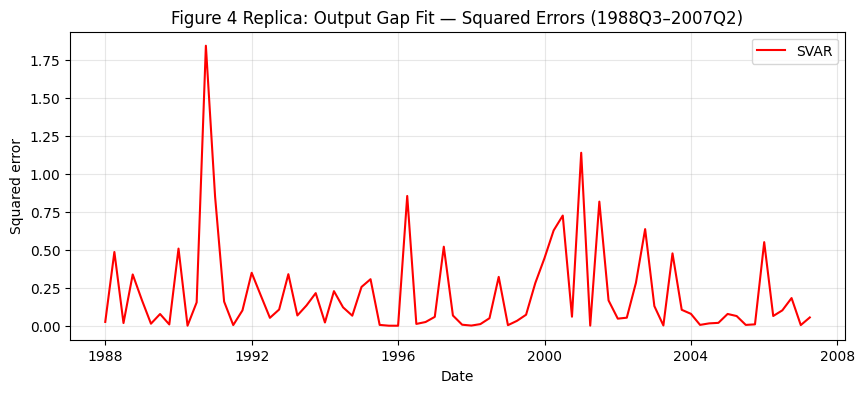

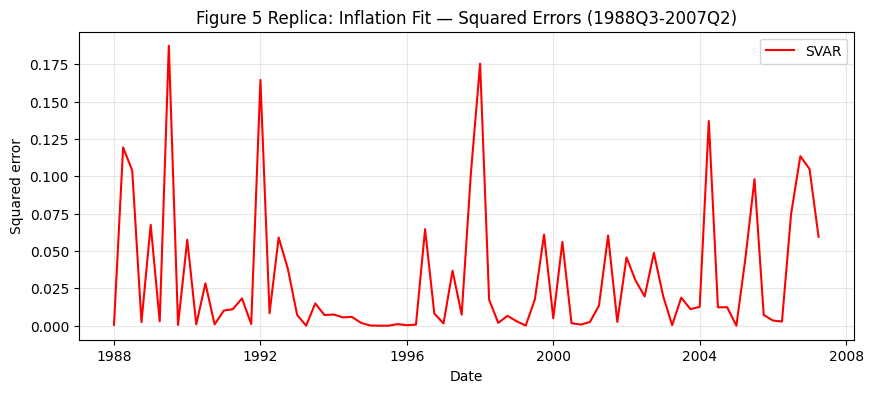

In [9]:
display(figure_seven)
display(figure_eight)

The SVAR squared errors plotted over time for the sample data range in our tests reflect the patternto a high degree ensuring us that our model is a good replica of the model used in the Bundesbankpaper.

## Citations

1. The pandas development team. pandas-dev/pandas: Pandas [Computer software]. https://doi.org/10.5281/zenodo.3509134

2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (Version 2.1.5) [Computer software]. https://doi.org/10.5281/zenodo.17180397

3. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

4. Skipper, S., & Josef, P. (2010). statsmodels: Econometric and statistical modeling with python. 9th Python in Science Conference

5. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

6. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

7. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. Deutsche Bundesbank. https://books.google.com/books?id=yjjIzgEACAAJ